#  YouTube Retention Model Evaluation

##  Objective
The goal of this notebook is to evaluate the effectiveness of the custom YouTube video ranking model by comparing it against a simple baseline approach.


In [7]:
import os
import pandas as pd

print("Current folder:", os.getcwd())

df = pd.read_csv("../outputs/scored_videos.csv")
df.head()

Current folder: d:\youtube-retention-project\notebooks


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,comment_ratio,day,hour,controversy,sentiment_score,views_n,engagement_n,sentiment_n,time_score,score
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,...,0.021318,Monday,17,0.003963,0.0,0.024975,0.301255,0.0,0.5,0.164181
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,...,0.005252,Monday,7,0.002541,0.0,0.080761,0.139390,0.0,0.5,0.127053
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,...,0.002563,Sunday,19,0.001673,0.0,0.106565,0.148257,0.0,1.0,0.189188
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,...,0.006253,Monday,11,0.001941,0.0,0.011442,0.110132,0.0,0.5,0.092551
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,...,0.008359,Sunday,18,0.000949,0.0,0.069972,0.219239,0.0,1.0,0.201224


In [8]:
df["true_score"] = df["likes"] + df["comment_count"]
df[["title", "score", "true_score"]].head()

,title,score,true_score
0,WE WANT TO TALK ABOUT OUR MARRIAGE,0.164181,73481
1,The Trump Presidency: Last Week Tonight with J...,0.127053,109888
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",0.189188,154214
3,Nickelback Lyrics: Real or Fake?,0.092551,12318
4,I Dare You: GOING BALD!?,0.201224,149753


In [9]:
def precision_at_k(df, score_col, k=10):
    top_k = df.sort_values(score_col, ascending=False).head(k)
    return top_k["true_score"].mean()

In [10]:
k = 10

results = {
    "Your Model (score)": precision_at_k(df, "score", k),
    "Views Only Baseline": precision_at_k(df, "views", k)
}

results

{'Your Model (score)': np.float64(2585481.9),
 'Views Only Baseline': np.float64(1214100.5)}

Saved at: D:\youtube-retention-project\reports\figures\model_comparison.png


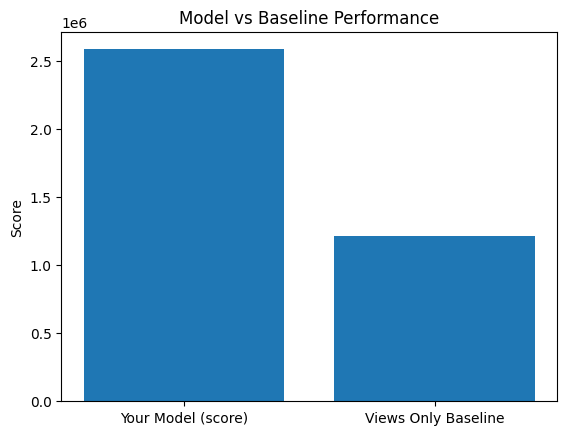

In [20]:
import matplotlib.pyplot as plt
import os

BASE_DIR = r"D:\youtube-retention-project"
FIG_DIR = os.path.join(BASE_DIR, "reports", "figures")

os.makedirs(FIG_DIR, exist_ok=True)

models = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(models, scores)
plt.title("Model vs Baseline Performance")
plt.ylabel("Score")

save_path = os.path.join(FIG_DIR, "model_comparison.png")
plt.savefig(save_path)

print("Saved at:", save_path)
plt.show()

C:\Users\sasip\AppData\Local\Temp\ipykernel_12608\2141964314.py:8: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, "top_k_rankings.png"))
C:\Users\sasip\AppData\Local\Temp\ipykernel_12608\2141964314.py:8: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, "top_k_rankings.png"))
C:\Users\sasip\AppData\Local\Temp\ipykernel_12608\2141964314.py:8: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, "top_k_rankings.png"))
C:\Users\sasip\AppData\Local\Temp\ipykernel_12608\2141964314.py:8: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, "top_k_rankings.png"))
C:\Users\sasip\AppData\Local\Temp\ipykernel_12608\2141964314.py:8: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  

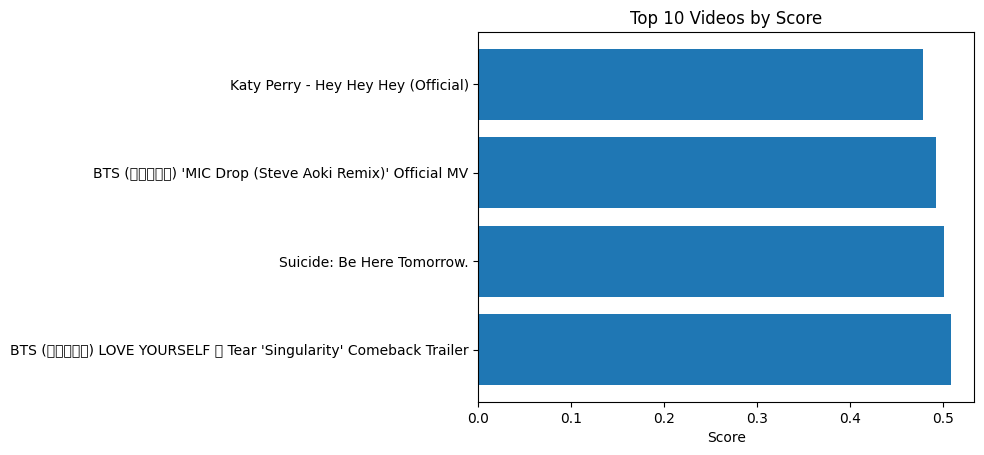

In [21]:
top_k = df.sort_values("score", ascending=False).head(10)

plt.figure()
plt.barh(top_k["title"], top_k["score"])
plt.title("Top 10 Videos by Score")
plt.xlabel("Score")

plt.savefig(os.path.join(FIG_DIR, "top_k_rankings.png"))
plt.show()

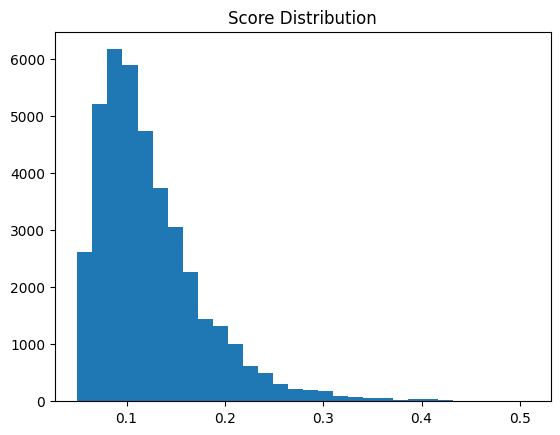

In [22]:
plt.figure()
plt.hist(df["score"], bins=30)
plt.title("Score Distribution")

plt.savefig(os.path.join(FIG_DIR, "score_distribution.png"))
plt.show()